# Retail Customer & Category Analysis — SQL + Python
**Author:** Enoch Effah  
**Dataset:** Superstore Orders (MySQL — superstore_db)  
**Tools:** MySQL, Python, pandas, matplotlib, seaborn  
**Date:** May 2026

## Project Overview
This notebook connects directly to a MySQL database to analyze customer 
profitability, category performance, and regional trends. SQL handles 
the data aggregation and filtering — Python handles the visualization 
and storytelling.

## Business Questions
1. Who are our most and least profitable customers?
2. Which product categories and sub-categories generate the most losses?
3. Which region and category combination is most and least profitable?

In [7]:
from dotenv import load_dotenv
import os

import mysql.connector
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


load_dotenv()

# Connect to MySQL
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password=os.environ.get("MYSQL_PASSWORD", ""),
    database="superstore_db"
)

print("Connection successful")

Connection successful


## Customer Profitability Analysis

**Business Question:** Who are our most and least profitable customers, 
and is high spending always correlated with high profit?

**Method:** We query customer sales, profit, profit margin, and 
average discount directly from MySQL. We filter for customers with 
total sales above $5,000 to remove low-volume customers whose margins 
may be misleading.

In [8]:
# Customer profitability

query = """ 
    SELECT 
        customer_name, 
        ROUND(SUM(sales), 2) AS total_sales, 
        ROUND(SUM(profit), 2) AS total_profit, 
        ROUND((SUM(profit) / SUM(sales) * 100), 2) AS profit_margin,
        ROUND(AVG(discount), 2) AS average_discount
    FROM orders
    GROUP BY customer_name
    HAVING total_sales > 5000
    ORDER BY profit_margin ASC;

"""

df_customers = pd.read_sql(query, conn)
print(df_customers.shape)
df_customers.head(10)

C:\Users\enoch\AppData\Local\Temp\ipykernel_42356\2589963626.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_customers = pd.read_sql(query, conn)


(115, 5)


,customer_name,total_sales,total_profit,profit_margin,average_discount
0,Cindy Stewart,5690.06,-6626.39,-116.46,0.20
1,Grant Thornton,9351.21,-4108.66,-43.94,0.25
2,Christine Phan,5888.28,-1850.30,-31.42,0.21
3,Sean Braxton,8057.89,-2082.75,-25.85,0.24
4,Tom Prescott,5329.00,-1087.39,-20.41,0.46
5,Natalie Fritzler,8322.83,-1695.97,-20.38,0.25
6,Becky Martin,11609.90,-1711.43,-14.74,0.19
7,Victoria Wilson,6112.70,-882.40,-14.44,0.16
8,Zuschuss Carroll,8021.14,-1028.34,-12.82,0.24
9,Joseph Airdo,6475.47,-825.06,-12.74,0.21


## Customer Profit Margin Analysis

**Key Insights:** This chart shows the 20 worst performing customers 
by profit margin, ranging from Grant Thornton at -43.94% to Mick 
Hernandez who barely breaks even at +3.11%. Note: Cindy Stewart was 
excluded as an extreme outlier at -116% profit margin and warrants 
separate investigation.

Grant Thornton is particularly alarming — the company generates $9,351 
in sales but loses $4,108, driven by a 25% average discount on 
high-value Machines purchases. Most problematic customers carry average 
discounts between 0.20 and 0.25.

**Recommendation:** Cap customer-level discounts at 20% maximum. 
Customers receiving discounts above this threshold consistently generate 
losses regardless of sales volume.

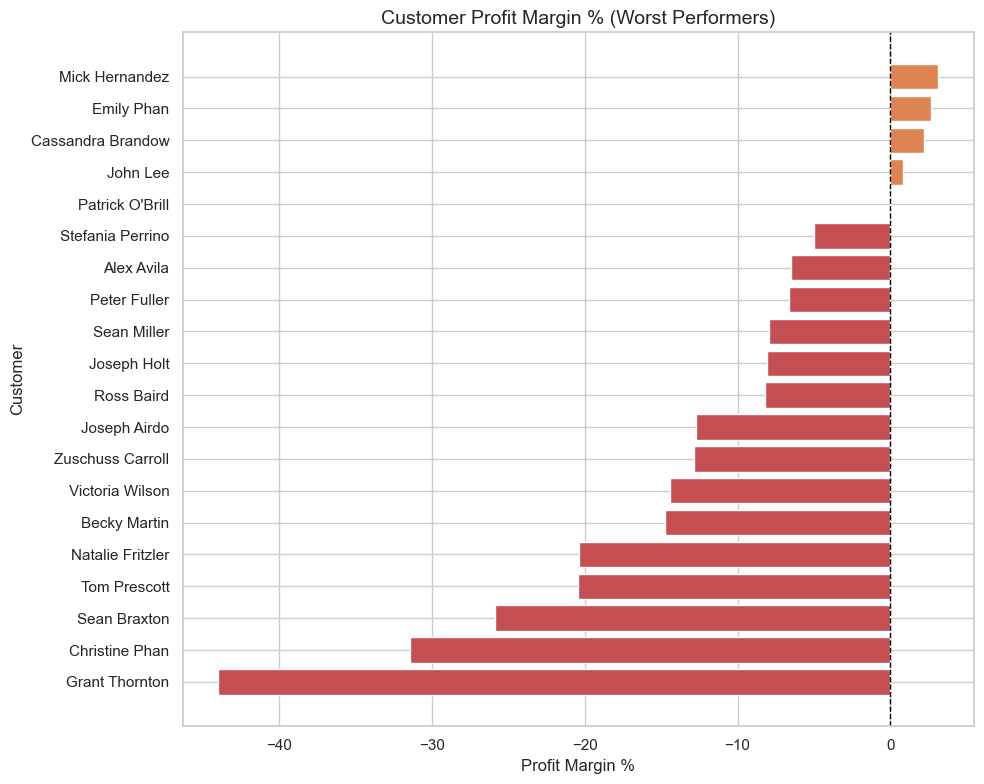

In [22]:
df_worst = df_customers[
    (df_customers["profit_margin"] < 10) & (df_customers["profit_margin"] > -50)
].head(20)

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(10, 8))

colors = ["#C44E52" if x < 0 else "#DD8452"
          for x in df_worst["profit_margin"]]

bars = ax.barh(df_worst["customer_name"], df_worst["profit_margin"], color = colors)

ax.axvline(x=0, color="black", linestyle="--", linewidth = 1)
ax.set_title("Customer Profit Margin % (Worst Performers)", fontsize=14)
ax.set_xlabel("Profit Margin %")
ax.set_ylabel("Customer")

plt.tight_layout()
plt.show()

## Sub-Category Profitability Analysis

**Business Question:** Which product categories and sub-categories 
are generating the most losses — and is the problem isolated to 
specific sub-categories or systemic across entire categories?

**Method:** We query total sales, total profit, and profit margin 
for every category and sub-category combination directly from MySQL. 
Results are sorted from worst to best margin so problem areas are 
immediately visible. No minimum sales filter is applied here since 
we want to see all sub-categories regardless of volume.

In [9]:
query2 = """ 
    SELECT
        category,
        sub_category,
        ROUND(SUM(sales), 2) AS total_sales,
        ROUND(SUM(profit), 2) AS total_profit,
        ROUND((SUM(profit) / SUM(sales)) * 100, 2) AS profit_margin
    FROM orders
    GROUP BY category, sub_category
    ORDER BY profit_margin ASC
"""

df_categories = pd.read_sql(query2, conn)
df_categories

C:\Users\enoch\AppData\Local\Temp\ipykernel_42356\148651163.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_categories = pd.read_sql(query2, conn)


,category,sub_category,total_sales,total_profit,profit_margin
0,Furniture,Tables,206965.53,-17725.48,-8.56
1,Furniture,Bookcases,114880.00,-3472.56,-3.02
2,Office Supplies,Supplies,45952.47,-1348.57,-2.93
3,Technology,Machines,189238.63,3384.76,1.79
4,Furniture,Chairs,328449.10,26590.17,8.10
5,Office Supplies,Storage,216803.21,21527.91,9.93
6,Technology,Phones,329753.09,44447.88,13.48
7,Furniture,Furnishings,82752.23,11588.64,14.00
8,Office Supplies,Binders,199905.72,29983.02,15.00
9,Office Supplies,Appliances,107532.16,18138.01,16.87


## Profit Margin by Sub-Category

**Key Insights:** Labels in the Office Supplies category leads all 
sub-categories with a 44.42% profit margin. Tables in the Furniture 
category has the lowest margin at -8.56%. Three sub-categories fall 
below the breakeven point: Tables and Bookcases in Furniture, and 
Supplies in Office Supplies — which is surprising given that Office 
Supplies is otherwise a healthy category.

Furniture is consistently underperforming across its sub-categories. 
This is not isolated to one or two bad orders — it is a structural 
pricing and discounting problem across the entire category that needs 
to be addressed company-wide.

Supplies in Office Supplies warrants a separate investigation. Unlike 
the Furniture issues which appear systemic, this looks more like a 
specific pricing or cost problem isolated to that sub-category.

**Recommendation:** Immediately review pricing and discount policies 
for Tables and Bookcases. Investigate Supplies in Office Supplies 
separately to determine whether losses are driven by discounting, 
high costs, or a small number of heavily discounted orders.

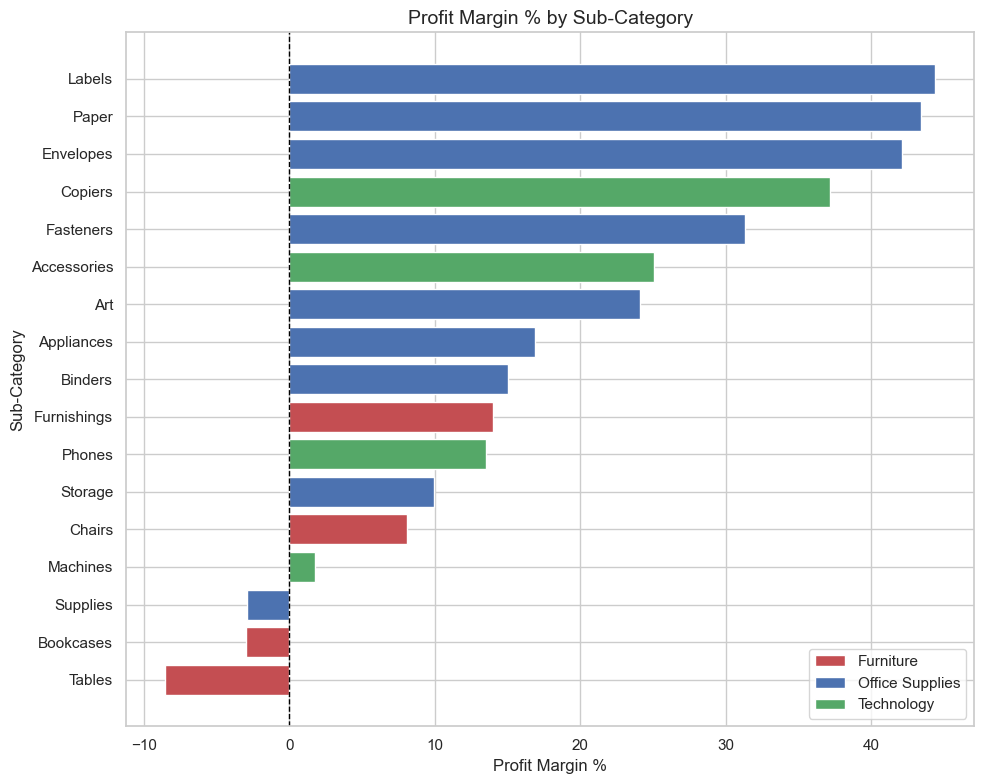

In [10]:
category_colors = {
    "Furniture": "#C44E52",
    "Office Supplies": "#4C72B0",
    "Technology": "#55A868"
}

colors = [category_colors[cat] for cat in df_categories["category"]] # For each iteration of the category column, look through category_colors and return the match. 

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(10, 8))

bars = ax.barh(df_categories["sub_category"],
               df_categories["profit_margin"],
               color = colors)

ax.axvline(x=0, color="black", linestyle="--", linewidth=1)
ax.set_title("Profit Margin % by Sub-Category", fontsize=14 )
ax.set_xlabel("Profit Margin %")
ax.set_ylabel("Sub-Category")

# Legend for categories
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#C44E52", label="Furniture"),
    Patch(facecolor="#4C72B0", label="Office Supplies"),
    Patch(facecolor="#55A868", label="Technology")
]
ax.legend(handles=legend_elements, loc="lower right")


plt.tight_layout()
plt.show()

## Region and Category Profitability Analysis

**Business Question:** Which region and category combination is most 
and least profitable — and is underperformance a regional problem 
or a category problem?

**Method:** We query total sales, total profit, and profit margin 
grouped by both region and category directly from MySQL. No minimum 
sales filter is applied since we want to see every combination 
regardless of volume. Results are sorted from worst to best margin 
to surface problem areas immediately.

In [11]:
query3 = """ 
    SELECT 
        region,
        category,
        ROUND(SUM(sales), 2) AS "total_sales",
        ROUND(SUM(profit), 2) AS "total_profit",
        ROUND((SUM(profit) / SUM(sales) * 100), 2) AS "profit_margin" 
    FROM orders
    GROUP BY region, category
    ORDER BY profit_margin ASC
"""

df_regions = pd.read_sql(query3, conn)
df_regions

C:\Users\enoch\AppData\Local\Temp\ipykernel_42356\3695065273.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_regions = pd.read_sql(query3, conn)


,region,category,total_sales,total_profit,profit_margin
0,Central,Furniture,162783.14,-2585.25,-1.59
1,East,Furniture,205540.35,2501.82,1.22
2,West,Furniture,248450.23,10588.42,4.26
3,Central,Office Supplies,164616.20,9020.72,5.48
4,South,Furniture,116273.14,6475.79,5.57
5,South,Technology,148730.52,19982.82,13.44
6,South,Office Supplies,123979.93,19577.08,15.79
7,West,Technology,251895.93,44271.28,17.58
8,East,Technology,264872.08,47439.56,17.91
9,Central,Technology,170401.53,33693.44,19.77


## Profit Margin % by Region and Category

**Key Insights:** Looking at this chart, the story is clear — Furniture 
is a problem in every single region, not just one. In the Central region, 
Furniture is the only category below the breakeven line at -1.59%, while 
Office Supplies and Technology are doing well at 5.48% and 19.77% 
respectively. This confirms that Central is not a broken region — it is 
carrying a broken category.

Across all four regions, Furniture consistently has the lowest margin. 
The West does the best job managing it at 4.26%, but even that is weak 
compared to what Office Supplies and Technology are delivering. Office 
Supplies leads in the West at 24.01% — the best performing 
region/category combination in the entire dataset.

**Recommendation:** The Furniture problem is company-wide and needs a 
company-wide fix. Regional managers should not be held accountable for 
these numbers until the pricing and discounting strategy for Furniture 
is addressed at the corporate level.

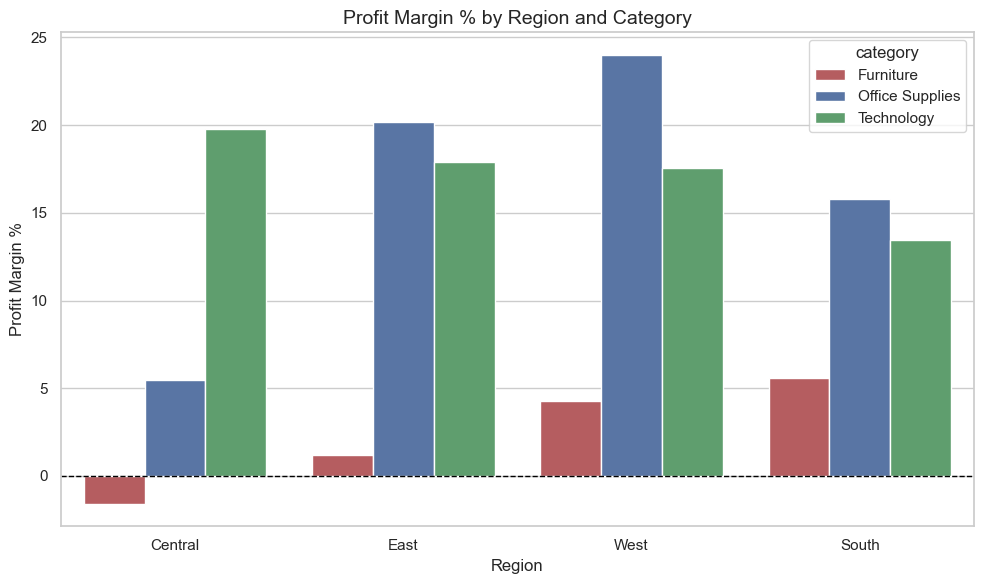

In [16]:
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=df_regions,
    x="region",
    y="profit_margin",
    hue="category",
    palette={
        "Furniture": "#C44E52",
        "Office Supplies": "#4C72B0",
        "Technology": "#55A868"
    },
    ax=ax
)

ax.axhline(y=0, color="black", linestyle="--", linewidth=1)
ax.set_title("Profit Margin % by Region and Category", fontsize=14)
ax.set_xlabel("Region")
ax.set_ylabel("Profit Margin %")

plt.tight_layout()
plt.show() 

## Key Findings & Recommendations

After analyzing the data, several important patterns stood out:

1. **Sean Miller generates the most sales, but he is not profitable**  
   Sean Miller had **$25,043 in sales**, but the company still lost **$1,980 in profit** from his orders. The main issue is that he receives a **25% discount on every order**, which is too high and is hurting profitability.

2. **Tables and Bookcases are losing money**  
   The **Tables** category has a margin of **-8.56%**, which means the company is losing money on these products. This does not seem to be only a discounting issue. The pricing strategy for these products may also need to be reviewed.

3. **Two customers had a major negative impact on Machines profitability**  
   Grant Thornton and Sean Miller both received **50% discounts** on Machines. These discounts almost eliminated the profit made by the entire Machines category.

4. **Furniture is a company-wide issue**  
   Furniture is struggling across every region, not just in one specific area. This suggests that the problem is not regional. It is likely connected to the overall pricing, discounting, or cost structure of the Furniture category.

5. **West Office Supplies is the strongest benchmark**  
   Office Supplies in the West region had a **24% profit margin**, which shows what strong performance looks like. This should be used as a benchmark when comparing other regions and categories.

## Recommendations

The company should limit discounts above **20%**, especially for customers and product categories that are already unprofitable. Furniture pricing should also be reviewed at the company level because the problem appears across all regions. Finally, the company should not measure success by sales volume alone. For example, Sean Miller looks like a top customer based on sales, but when profit is considered, he is actually costing the company money.